# FZP Cascade Comparison vs Element Number

This notebook plots focusing efficiency as a function of cascade depth \(N\) for three optics at the same aperture and aspect ratio (thickness / minimum feature size = 8):

- an **optimized diffractive cascade** (mean \(\pm\) std over independent random initializations)
- an **intermediate-field cascade of Fresnel zone plates** whose focal lengths coincide at the target plane: the upstream plate fills the cascade aperture and downstream radii follow the first-order cone
- a **single Fresnel zone plate** at the last-element focal length (independent of \(N\))

Load results produced by `paper/experiments/fzp_cascade_nelem_sweep.py`.

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

In [17]:
import sys
from pathlib import Path

repo_root = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(repo_root))

In [18]:
matplotlib.rcParams['figure.dpi'] = 200
matplotlib.rcParams.update({'font.size': 24})

## Load sweep results

Prefer the stable untimestamped files written for this notebook. If those are missing, fall back to the latest timestamped run in `paper_data/`.

In [19]:
path = repo_root / "paper_data"
prefix = "fzp_cascade_nelem_sweep"
params_path = path / f"{prefix}_params.npy"
results_path = path / f"{prefix}_results.npz"

if not params_path.exists() or not results_path.exists():
    param_candidates = sorted(path.glob(f"{prefix}_params_*.npy"))
    if not param_candidates:
        raise FileNotFoundError(
            f"No {prefix} results in {path}. Run paper/experiments/fzp_cascade_nelem_sweep.py first."
        )
    params_path = param_candidates[-1]
    results_path = path / params_path.name.replace("_params_", "_results_").replace(".npy", ".npz")

params = np.load(params_path, allow_pickle=True).item()
results = np.load(results_path, allow_pickle=True)
print(params_path.name)
print(results_path.name)

nelems = np.asarray(results["nelems"], dtype=int).reshape(-1)
opt_efficiencies = np.asarray(results["opt_efficiencies"], dtype=float)
if opt_efficiencies.ndim == 1:
    opt_efficiencies = opt_efficiencies[np.newaxis, :]
opt_efficiencies_mean = np.nanmean(opt_efficiencies, axis=0)
opt_efficiencies_std = np.nanstd(opt_efficiencies, axis=0)
n_runs = int(results["n_runs"]) if "n_runs" in results.files else int(opt_efficiencies.shape[0])
fzp_cascade_efficiencies = np.asarray(results["fzp_cascade_efficiencies"], dtype=float).reshape(-1)
fzp_efficiency = float(np.asarray(results["fzp_efficiency"]).reshape(-1)[0])
fzp_efficiencies = np.full(nelems.shape, fzp_efficiency, dtype=float)

colors = ["C0", "C1", (0.4, 0.651, 0.118)]

fzp_cascade_nelem_sweep_params.npy
fzp_cascade_nelem_sweep_results.npz


## Efficiency vs \(N\)

The single zone plate does not depend on cascade depth, so its efficiency is constant. The FZP cascade is deterministic and re-designed once at each \(N\). The optimized cascade is run multiple times per \(N\); the plot shows the mean with error bars of one standard deviation.

In [20]:
print(
    f"AR = {params['aspect_ratio']:.0f}, "
    f"E = {params['central_energy_ev']/1e3:.0f} keV, "
    f"n_runs = {n_runs}, "
    f"single FZP efficiency = {fzp_efficiency:.4f}"
)
print(f"{'N':>4} {'opt. cascade':>20} {'FZP cascade':>14} {'single FZP':>14}")
for n, opt_m, opt_s, casc_e, fzp_e in zip(
    nelems,
    opt_efficiencies_mean,
    opt_efficiencies_std,
    fzp_cascade_efficiencies,
    fzp_efficiencies,
):
    print(f"{int(n):4d} {opt_m:9.4f} ± {opt_s:.4f} {casc_e:14.4f} {fzp_e:14.4f}")

AR = 8, E = 10 keV, n_runs = 3, single FZP efficiency = 0.0272
   N         opt. cascade    FZP cascade     single FZP
   1    0.0081 ± 0.0006         0.0272         0.0272
   2    0.0411 ± 0.0025         0.0949         0.0272
   3    0.1011 ± 0.0095         0.1706         0.0272
   4    0.1703 ± 0.0097         0.2351         0.0272
   5    0.2328 ± 0.0017         0.2817         0.0272
   8    0.3455 ± 0.0018         0.2673         0.0272
  10    0.3852 ± 0.0029         0.1744         0.0272
  12    0.4039 ± 0.0035         0.0832         0.0272
  15    0.4125 ± 0.0014         0.0280         0.0272
  20    0.3988 ± 0.0097         0.0574         0.0272
  25    0.3659 ± 0.0023         0.0451         0.0272
  30    0.3646 ± 0.0073         0.0241         0.0272


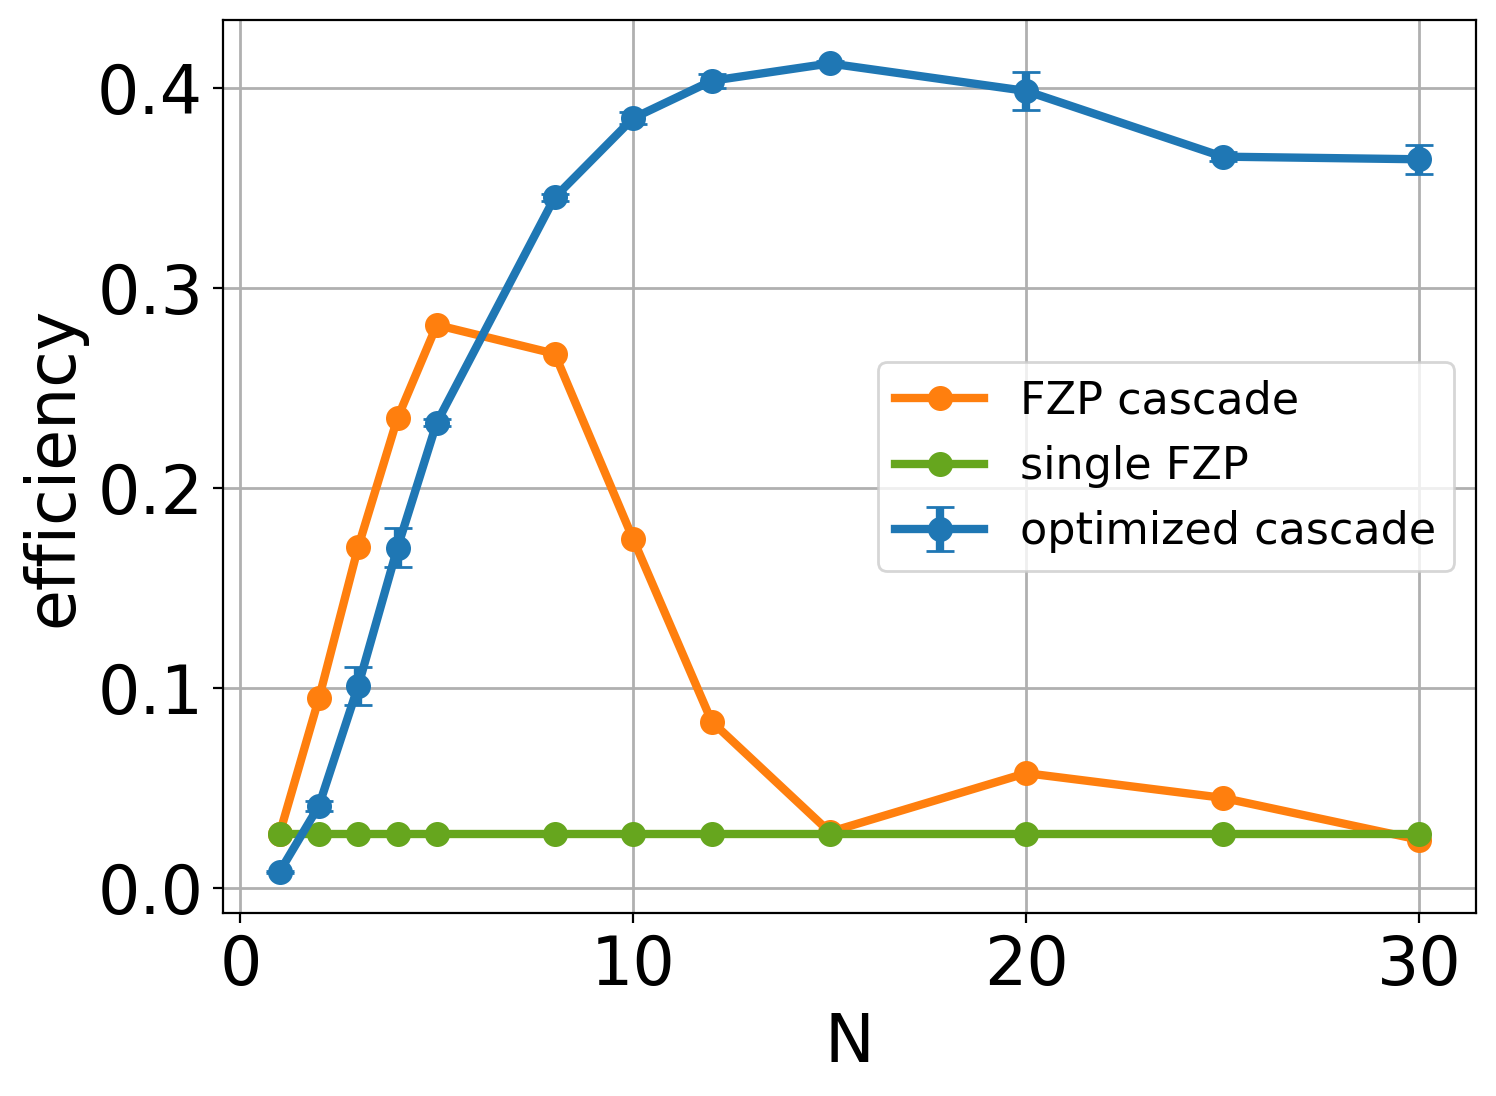

In [21]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.errorbar(
    nelems, opt_efficiencies_mean, yerr=opt_efficiencies_std,
    fmt="-o", linewidth=3, markersize=8, capsize=5, color=colors[0],
    label="optimized cascade",
)
ax.plot(
    nelems, fzp_cascade_efficiencies,
    "-o", linewidth=3, markersize=8, color=colors[1], label="FZP cascade",
)
ax.plot(
    nelems, fzp_efficiencies,
    "-o", linewidth=3, markersize=8, color=colors[2], label="single FZP",
)
ax.set_xlabel("N")
ax.set_ylabel("efficiency")
ax.legend(fontsize=16)
ax.grid(True, linewidth=1)
fig.tight_layout()
plt.savefig("fzp_cascade_nelem_sweep.png")